<a href="https://colab.research.google.com/github/williammazani-Chemist/Plant-based-corrosion-inhibition-analysis-/blob/main/Corrosion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corrosion Inhibition of Mild Steel Using Plant Extract

## Experimental Data Analysis Using Python

**Author:** William Mazani

### Project Overview

This notebook presents the analysis of gravimetric and FTIR experimental data obtained during the investigation of the corrosion inhibition performance of a plant extract on mild steel in acidic medium.

The analysis includes:

- Data loading
- Data cleaning
- Exploratory data analysis
- Gravimetric analysis
- FTIR spectral analysis
- Scientific visualization
- Interpretation of experimental results

The entire workflow is implemented in Python using Google Colab to ensure reproducibility and transparency.

## Objectives

The objectives of this notebook are:

1. Import experimental datasets.
2. Inspect and clean the data.
3. Analyze gravimetric measurements.
4. Visualize corrosion behavior.
5. Compare FTIR spectra.
6. Interpret the experimental findings using Python.

In [ ]:

# ============================================
# Import required Python libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

# Improve default figure resolution
plt.rcParams["figure.dpi"] = 120

In [ ]:

# ============================================
# Load experimental datasets
# ============================================

grav = pd.read_csv("gravimetric_result.csv")
ftir = pd.read_csv("ftir_corrosion_extract_data.csv")

In [ ]:

# ============================================
# Display the first five rows of each dataset
# ============================================

print("Gravimetric Dataset")
display(grav.head())

print("\nFTIR Dataset")
display(ftir.head())

Gravimetric Dataset


,inhibitor_conc,exposure_time,wight_loss,surface_coverage,IE,corrosion_rate
0,0,24,4.25,0.000,0.0,49.34
1,0,48,7.56,0.000,0.0,43.88
2,0,72,9.88,0.000,0.0,38.23
3,10,24,3.75,0.354,35.4,43.54
4,10,48,6.54,0.314,31.4,37.96



FTIR Dataset


,Wavenumber,Pure_Extract_Transmittance,Adsorbed_Extract_Transmittance
0,4000.0,93.72,94.11
1,3992.8,93.83,93.89
2,3985.6,93.98,94.14
3,3978.4,93.81,94.38
4,3971.1,94.14,93.97


In [ ]:

# ============================================
# Dataset information
# ============================================

print("Gravimetric Dataset Information")
grav.info()

print("\nFTIR Dataset Information")
ftir.info()

Gravimetric Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   inhibitor_conc    18 non-null     int64  
 1   exposure_time     18 non-null     int64  
 2   wight_loss        18 non-null     float64
 3   surface_coverage  18 non-null     float64
 4   IE                18 non-null     float64
 5   corrosion_rate    18 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 996.0 bytes

FTIR Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Wavenumber                      500 non-null    float64
 1   Pure_Extract_Transmittance      500 non-null    float64
 2   Adsorbed_Extract_Transmittance  500 non-null    float64


In [ ]:

# ============================================
# Summary statistics
# ============================================

grav.describe()

,inhibitor_conc,exposure_time,wight_loss,surface_coverage,IE,corrosion_rate
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,25.000000,48.000000,4.668889,0.356389,35.638889,28.027778
std,17.573376,20.164033,2.557867,0.191986,19.198626,12.139548
min,0.000000,24.000000,0.650000,0.000000,0.000000,7.550000
25%,10.000000,24.000000,3.110000,0.302000,30.200000,18.267500
50%,25.000000,48.000000,3.920000,0.371000,37.100000,27.280000
75%,40.000000,72.000000,6.302500,0.486000,48.600000,37.497500
max,50.000000,72.000000,9.880000,0.648000,64.800000,49.340000


In [ ]:

# ============================================
# Check for missing values
# ============================================

print("Missing values in Gravimetric Dataset")
print(grav.isnull().sum())

print("\nMissing values in FTIR Dataset")
print(ftir.isnull().sum())

Missing values in Gravimetric Dataset
inhibitor_conc      0
exposure_time       0
wight_loss          0
surface_coverage    0
IE                  0
corrosion_rate      0
dtype: int64

Missing values in FTIR Dataset
Wavenumber                        0
Pure_Extract_Transmittance        0
Adsorbed_Extract_Transmittance    0
dtype: int64


In [ ]:

# ============================================
# Clean column names
# ============================================

grav.columns = grav.columns.str.strip()
ftir.columns = ftir.columns.str.strip()

print("Gravimetric Columns:")
print(grav.columns)

print("\nFTIR Columns:")
print(ftir.columns)

Gravimetric Columns:
Index(['inhibitor_conc', 'exposure_time', 'wight_loss', 'surface_coverage',
       'IE', 'corrosion_rate'],
      dtype='object')

FTIR Columns:
Index(['Wavenumber', 'Pure_Extract_Transmittance',
       'Adsorbed_Extract_Transmittance'],
      dtype='object')


## Exploratory Data Analysis (EDA)

Before performing any visualization, it is important to understand the structure and quality of the experimental datasets. This section examines the distribution, completeness, and consistency of the gravimetric and FTIR data.

In [ ]:

# ============================================
# Number of observations and variables
# ============================================

print(f"Gravimetric dataset shape: {grav.shape}")
print(f"FTIR dataset shape: {ftir.shape}")

Gravimetric dataset shape: (18, 6)
FTIR dataset shape: (500, 3)


In [ ]:

# ============================================
# List all variables
# ============================================

print("Gravimetric Variables")
print(list(grav.columns))

print("\nFTIR Variables")
print(list(ftir.columns))

Gravimetric Variables
['inhibitor_conc', 'exposure_time', 'wight_loss', 'surface_coverage', 'IE', 'corrosion_rate']

FTIR Variables
['Wavenumber', 'Pure_Extract_Transmittance', 'Adsorbed_Extract_Transmittance']


### Observation

The gravimetric dataset contains experimental measurements related to corrosion performance, including weight loss, corrosion rate, inhibition efficiency, and surface coverage.

The FTIR dataset contains the spectral information of the pure plant extract and the adsorbed extract, which will be compared to identify possible adsorption-related changes.

# Weight Loss Analysis

Weight loss is one of the most direct indicators of corrosion. Lower weight loss indicates better corrosion protection provided by the plant extract.

This section examines the relationship between inhibitor concentration and weight loss at different exposure times.

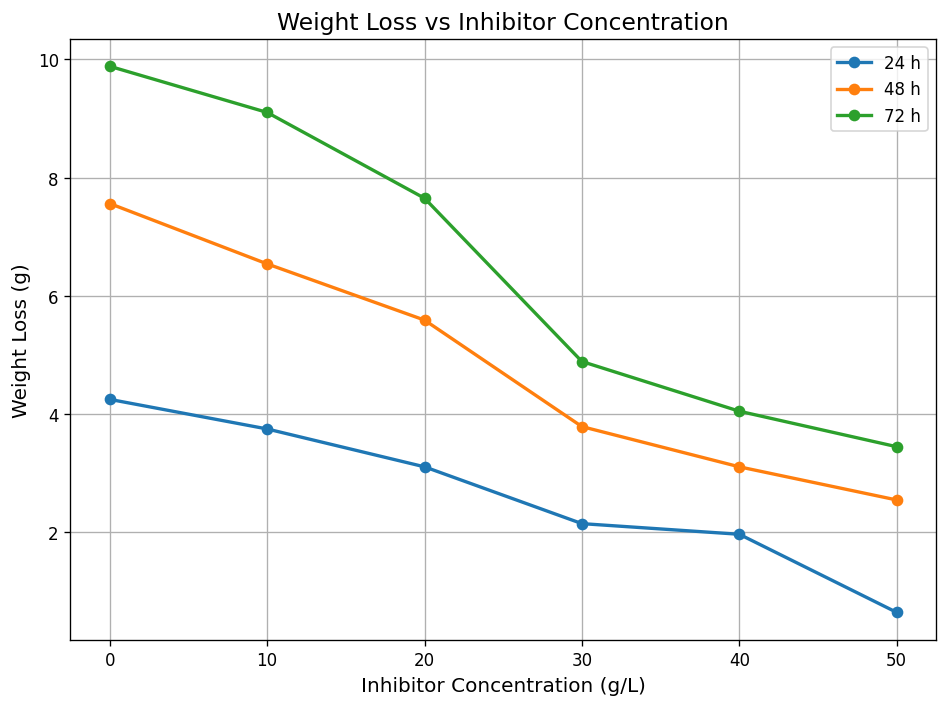

In [ ]:

# ============================================
# Create a figure
# ============================================

plt.figure(figsize=(8,6))

# Plot weight loss for each exposure time
for time in grav["exposure_time"].unique():

    subset = grav[grav["exposure_time"] == time]

    plt.plot(
        subset["inhibitor_conc"],
        subset["wight_loss"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"{time} h"
    )

# Figure formatting
plt.title("Weight Loss vs Inhibitor Concentration", fontsize=14)

plt.xlabel("Inhibitor Concentration (g/L)", fontsize=12)

plt.ylabel("Weight Loss (g)", fontsize=12)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The weight loss of mild steel decreased as the inhibitor concentration increased, indicating that the plant extract effectively reduced metal dissolution in the acidic medium. This trend suggests that increasing the inhibitor concentration enhanced the formation of a protective adsorbed layer on the mild steel surface, thereby improving corrosion resistance. The observed behavior demonstrates the concentration-dependent corrosion inhibition performance of the plant extract.

## Corrosion Rate Analysis

Corrosion rate is an important parameter for evaluating the effectiveness of a corrosion inhibitor. A lower corrosion rate indicates improved protection of mild steel against corrosion.

This section examines the variation of corrosion rate with inhibitor concentration at different exposure times.

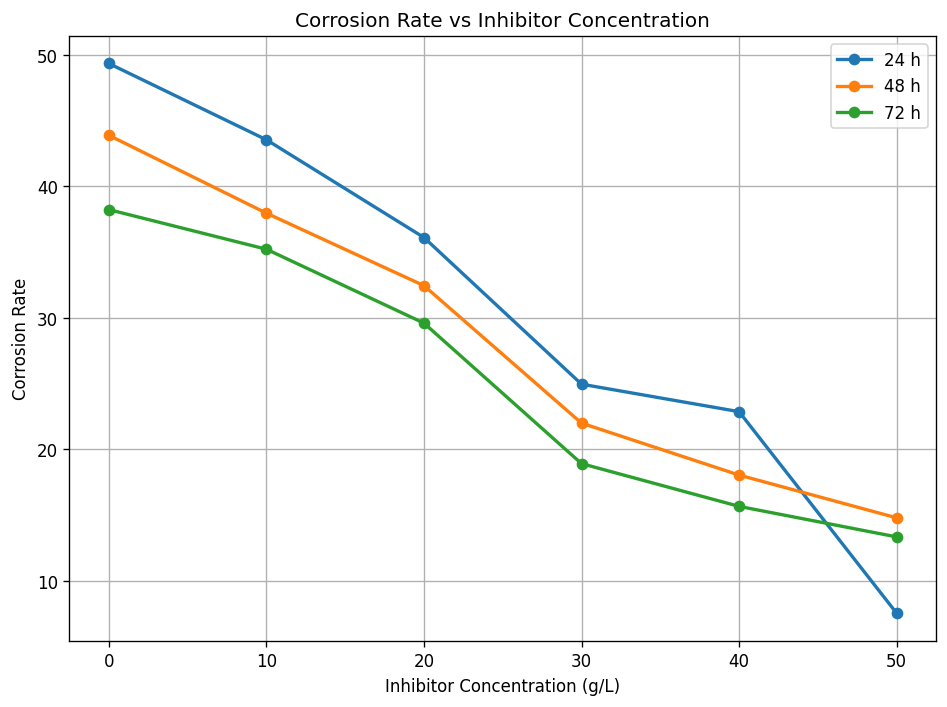

In [13]:

# ============================================
# Corrosion Rate Analysis
# ============================================

plt.figure(figsize=(8,6))

for time in grav["exposure_time"].unique():

    subset = grav[grav["exposure_time"] == time]

    plt.plot(
        subset["inhibitor_conc"],
        subset["corrosion_rate"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"{time} h"
    )

plt.title("Corrosion Rate vs Inhibitor Concentration")

plt.xlabel("Inhibitor Concentration (g/L)")

plt.ylabel("Corrosion Rate")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The corrosion rate decreased with increasing inhibitor concentration, indicating that the plant extract effectively reduced the corrosion of mild steel. The reduction became more pronounced at higher inhibitor concentrations, demonstrating improved corrosion protection.

# Inhibition Efficiency Analysis

Inhibition efficiency represents the ability of the plant extract to reduce corrosion. Higher inhibition efficiency indicates better corrosion protection.

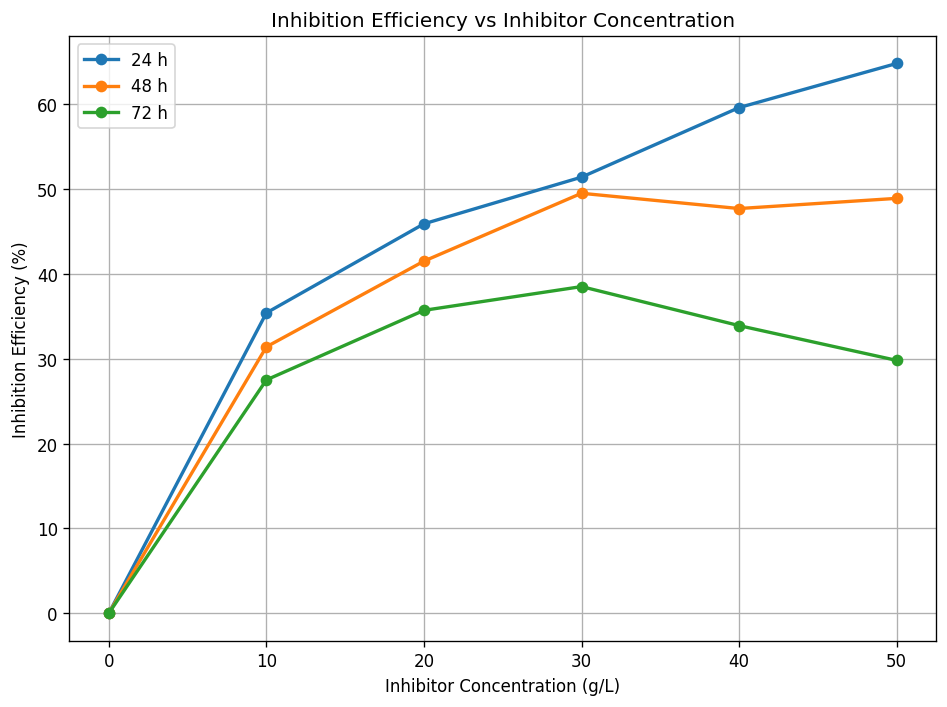

In [14]:

# ============================================
# Inhibition Efficiency Analysis
# ============================================

plt.figure(figsize=(8,6))

for time in grav["exposure_time"].unique():

    subset = grav[grav["exposure_time"] == time]

    plt.plot(
        subset["inhibitor_conc"],
        subset["IE"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"{time} h"
    )

plt.title("Inhibition Efficiency vs Inhibitor Concentration")

plt.xlabel("Inhibitor Concentration (g/L)")

plt.ylabel("Inhibition Efficiency (%)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The inhibition efficiency increased with increasing inhibitor concentration, confirming that the plant extract became more effective in suppressing corrosion at higher concentrations.

# Langmuir Adsorption Isotherm

The Langmuir adsorption isotherm was employed to investigate the adsorption behavior of the plant extract on the mild steel surface. The model assumes monolayer adsorption on a homogeneous surface with identical adsorption sites.

The linear form of the Langmuir equation is expressed as:

\[
\frac{C}{\theta}= \frac{1}{K_{ads}} + C
\]

where:

- \(C\) is the inhibitor concentration,
- \(\theta\) is the surface coverage,
- \(K_{ads}\) is the adsorption equilibrium constant.

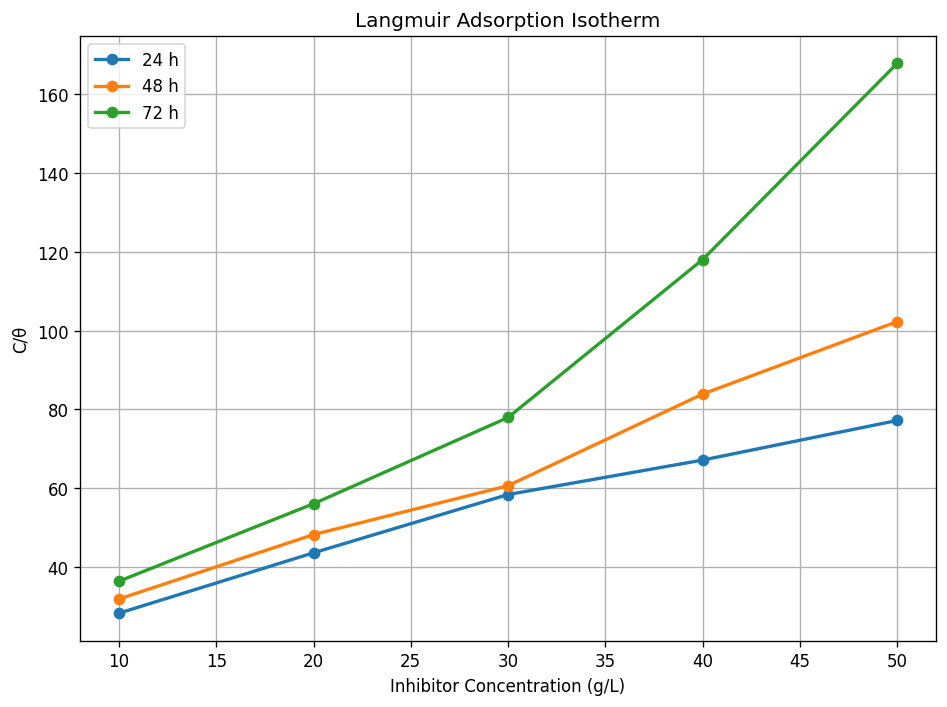

In [16]:

# ============================================
# Langmuir Adsorption Isotherm
# ============================================

# Calculate C/theta
grav["C_theta"] = grav["inhibitor_conc"] / grav["surface_coverage"]

plt.figure(figsize=(8,6))

for time in grav["exposure_time"].unique():

    subset = grav[grav["exposure_time"] == time]

    plt.plot(
        subset["inhibitor_conc"],
        subset["C_theta"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"{time} h"
    )

plt.title("Langmuir Adsorption Isotherm")

plt.xlabel("Inhibitor Concentration (g/L)")

plt.ylabel("C/θ")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The approximately linear relationship between \(C/\theta\) and inhibitor concentration suggests that the adsorption of the plant extract on the mild steel surface follows the Langmuir adsorption model. This indicates the formation of a protective monolayer of inhibitor molecules on the metal surface.

# FTIR Spectral Analysis

Fourier Transform Infrared (FTIR) spectroscopy was used to compare the functional groups present in the pure plant extract and the adsorbed extract after corrosion inhibition. The comparison of the spectra provides evidence for the adsorption of inhibitor molecules onto the mild steel surface.

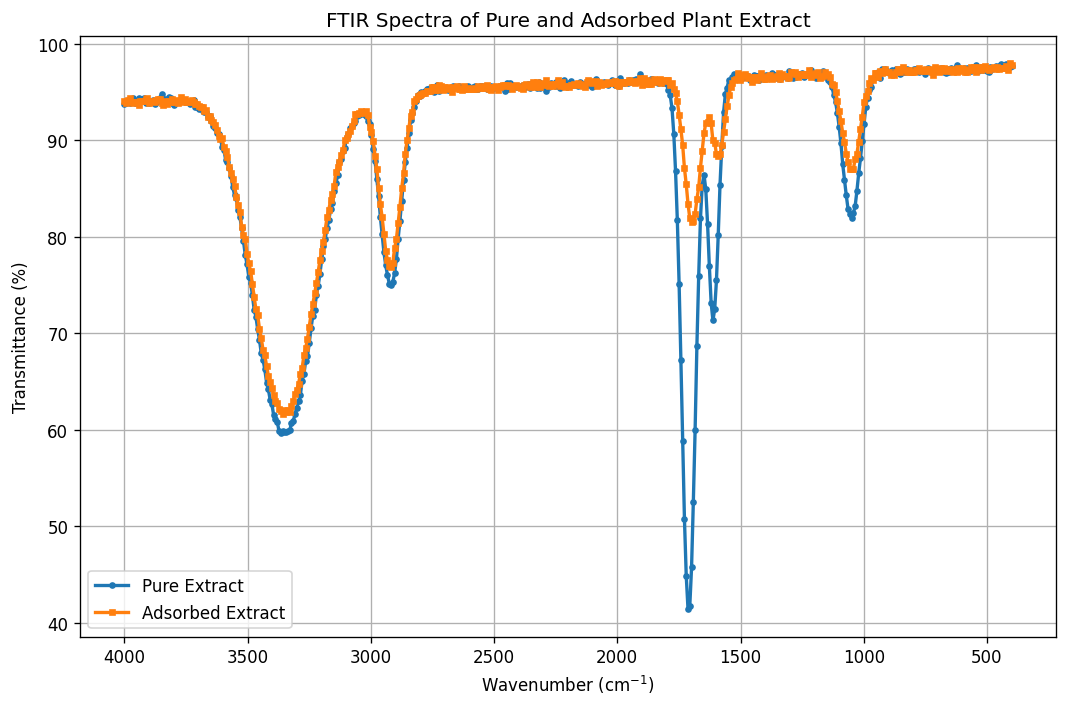

In [17]:

# ============================================
# FTIR Spectral Analysis
# ============================================

plt.figure(figsize=(9,6))

plt.plot(
    ftir["Wavenumber"],
    ftir["Pure_Extract_Transmittance"],
    marker="o",
    linewidth=2,
    markersize=3,
    label="Pure Extract"
)

plt.plot(
    ftir["Wavenumber"],
    ftir["Adsorbed_Extract_Transmittance"],
    marker="s",
    linewidth=2,
    markersize=3,
    label="Adsorbed Extract"
)

# FTIR spectra are conventionally displayed with decreasing wavenumber
plt.gca().invert_xaxis()

plt.title("FTIR Spectra of Pure and Adsorbed Plant Extract")

plt.xlabel("Wavenumber (cm$^{-1}$)")

plt.ylabel("Transmittance (%)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretation

The FTIR spectra showed noticeable differences between the pure plant extract and the adsorbed extract. Variations in peak positions and transmittance intensities indicate the interaction of the plant extract with the mild steel surface. These spectral changes suggest that the active phytochemical constituents were adsorbed onto the metal surface, forming a protective layer that contributed to corrosion inhibition.

# Key Findings

- Weight loss decreased with increasing inhibitor concentration.
- Corrosion rate decreased as inhibitor concentration increased.
- Inhibition efficiency improved with increasing inhibitor concentration.
- The Langmuir adsorption model suggested monolayer adsorption of the inhibitor on the mild steel surface.
- FTIR analysis confirmed the adsorption of the plant extract onto the mild steel surface through changes in spectral characteristics.

# Conclusion

The Python-based analysis demonstrated that the plant extract effectively inhibited the corrosion of mild steel in the acidic medium. Gravimetric analysis showed a reduction in weight loss and corrosion rate, accompanied by an increase in inhibition efficiency with increasing inhibitor concentration. The Langmuir adsorption isotherm indicated that the adsorption process was consistent with monolayer adsorption, while FTIR analysis provided spectroscopic evidence of the adsorption of the inhibitor molecules onto the mild steel surface. These findings confirm the potential of the investigated plant extract as an environmentally friendly corrosion inhibitor.